In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [31]:
df = pd.read_csv("../kmeans_activity_dataset.csv")

print(df.head())
print(df.tail())

  Customer  Income_k  Spending_Score
0      C01      18.8            22.4
1      C02      15.4            26.1
2      C03      19.9            22.1
3      C04      20.4            27.6
4      C05      13.1            24.9
   Customer  Income_k  Spending_Score
40      C41      88.2            33.5
41      C42      88.6            30.6
42      C43      89.2            32.0
43      C44      93.5            33.4
44      C45      92.4            33.3


In [ ]:
print(df.describe())

In [ ]:
X = df[['Income_k', 'Spending_Score']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# X_scaled = StandardScaler.fit_transform(X)

In [ ]:
inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(
        n_clusters = k,
        n_init = 10,
        random_state = 42
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

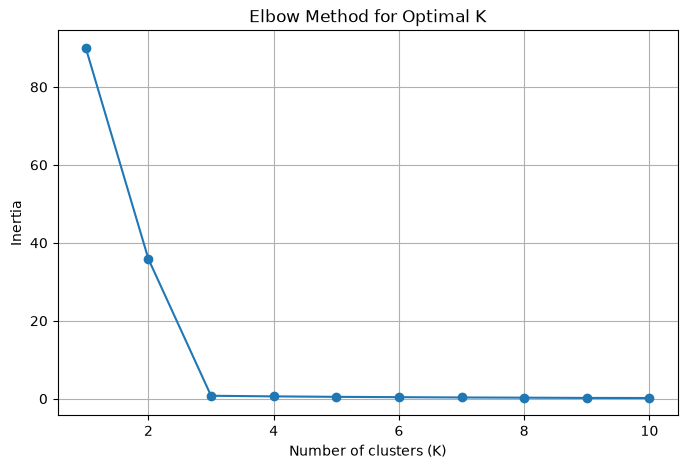

In [32]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker= 'o')

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)
plt.show()


In [ ]:
# Training the final model with k=3
kmeans = KMeans(
    n_clusters = 3,
    n_init = 10,
    random_state = 42
)

clusters = kmeans.fit_predict(X_scaled)
df['Cluster']= clusters

In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

#check the shape
print('Data shape', X.shape)
print('Cluster Centers shape:', centers.shape)
print('scaled data shape:', X_scaled.shape)

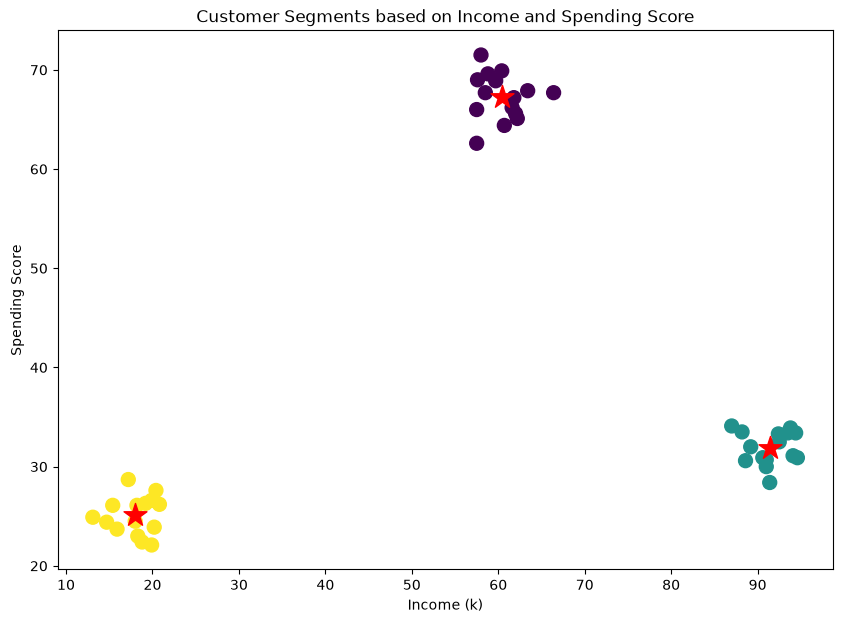

In [36]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df['Income_k'],
    df['Spending_Score'],
    c = clusters,
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    c='red',
    label='Centroids',
    marker='*',
    
)

plt.xlabel('Income (k)')
plt.ylabel('Spending Score')
plt.title('Customer Segments based on Income and Spending Score')

plt.show()